# 14 · Resumen explicado: del LSTM de 2025 al LSTM multianual (2020–2026)

Este libro **cuenta toda la historia con gráficas**: qué problema atacamos, qué hacía
el detector cuando sólo teníamos 2025, qué cambió al tener siete años, cómo aprendió,
cómo se calibró y cómo le fue contra los ataques.

- **No entrena, no recalibra y no cambia ningún resultado.** Sólo lee lo que ya está
  guardado (notebooks 07, 09, 10–13).
- Cada sección tiene un recuadro **«Antes (sólo 2025)»** frente a **«Ahora (2020–2026)»**.
- Todos los números del multianual vienen de los modelos de
  `results/lstm_v4_multianual_v1/estaciones/` (entrenados el 2026-10-03, cargados de
  disco). Los de 2025 vienen de `results/` y `results/multiestacion_v4_p95_2025/`.
- Si un término no te queda claro, la sección 0 del notebook 12 lo explica desde cero.

**Índice**

1. El problema: voltear un bit
2. Antes y ahora: cómo se repartieron los datos
3. Los datos de siete años
4. Qué ve el modelo para estimar una hora
5. Cómo aprendió (épocas, error, sobreajuste)
6. Calibración: el umbral de alerta
7. ¿El LSTM sirve más que el perfil?
8. Sin ataques: falsas alarmas en años nuevos
9. Por qué unos bits se detectan y otros no
10. Resultados contra ataques, antes y ahora
11. Daño que se escapa: el punto ideal del atacante
12. Las estaciones sin detector
13. Resumen final

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')
from src.detect import multianual as m
from src.detect import entrenamiento_multianual as em
from src.detect import ataques_multianual as at

SAL = RAIZ / 'results/lstm_v4_multianual_v1'
EST = SAL / 'estaciones'
R25 = RAIZ / 'results/multiestacion_v4_p95_2025'
IMG = RAIZ / 'docs/img/lstm_v4_multianual_v1/resumen'
IMG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 200)

# Estilo: paleta categórica validada (sólo los 3 primeros espacios para años), gris neutro
# para referencias, rojo reservado al umbral de 155 ppb, líneas finas y rejilla tenue.
AZUL, NARANJA, AQUA, AMARILLO = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
TINTA, TINTA2, GRIS, CRITICO = '#0b0b0b', '#52514e', '#9a9893', '#e34948'
COLOR_ANIO = {2024: AZUL, 2025: NARANJA, 2026: AQUA}
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb',
    'axes.edgecolor': GRIS, 'axes.labelcolor': TINTA2, 'xtick.color': TINTA2, 'ytick.color': TINTA2,
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2,
    'lines.markersize': 6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})
def guardar(fig, nombre):
    fig.savefig(IMG / f'{nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [2]:
# Datos: matriz, predicciones (se regeneran desde los modelos si no están) y tablas guardadas
ctx = em.contexto(RAIZ)
pred = at.cargar_predicciones(EST, ctx)
cob = pd.read_csv(SAL / 'cobertura_etapas.csv')
CLASES = cob.drop_duplicates('objetivo').set_index('objetivo')['clasificacion']
estado = pd.read_csv(SAL / 'estado_objetivos.csv')
limpias = pd.read_csv(SAL / 'metricas_limpias.csv')
pareada = pd.read_csv(SAL / 'metricas_pareadas_agregadas.csv')
dias = pd.read_csv(SAL / 'resumen_dano_dias.csv')
geo = pd.read_csv(RAIZ / 'results/inventario_multianual/estaciones_geografia.csv', index_col=0)
print('Objetivos entrenados:', int(estado.entrenado.sum()), '| filas de predicción:', len(pred))

Objetivos entrenados: 31 | filas de predicción: 533649


## 1. El problema: voltear un bit

Cada estación manda su lectura de ozono como un **número entero** dentro de un mensaje
LoRaWAN cifrado. Una computadora guarda los enteros en **binario**: una fila de
casillas que valen 0 o 1, y cada casilla tiene un **peso** (1, 2, 4, 8, 16, 32, 64, 128).
El número es la suma de los pesos de las casillas en 1.

El cifrado de LoRaWAN (AES en modo contador) tiene una debilidad: si alguien **voltea
una casilla del mensaje cifrado**, al descifrarlo queda volteada **la misma casilla**
del número original. El atacante no necesita la clave. A esto se le llama *bit flipping*.

Voltear el bit *k* suma 2^k si la casilla estaba en 0, o lo resta si estaba en 1. El
atacante ciego **no sabe** cuál de las dos cosas pasará.

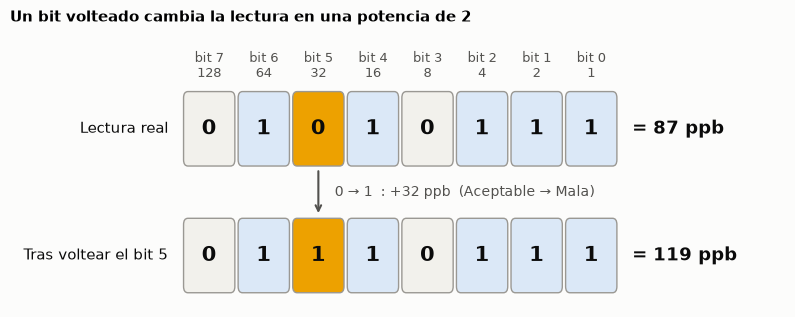

In [3]:
def dibujar_binario(ax, valor, y, resaltar=None, titulo=''):
    bits = [(valor >> k) & 1 for k in range(7, -1, -1)]
    for i, b in enumerate(bits):
        k = 7 - i
        color = AMARILLO if k == resaltar else ('#dbe8f7' if b else '#f2f1ec')
        ax.add_patch(mpatches.FancyBboxPatch((i, y), 0.9, 0.9, boxstyle='round,pad=0.02,rounding_size=0.08',
                                             fc=color, ec=GRIS, lw=1))
        ax.text(i + 0.45, y + 0.45, str(b), ha='center', va='center', fontsize=15, color=TINTA, weight='bold')
    ax.text(-0.3, y + 0.45, titulo, ha='right', va='center', fontsize=11, color=TINTA)
    ax.text(8.2, y + 0.45, f'= {valor} ppb', ha='left', va='center', fontsize=13, color=TINTA, weight='bold')

fig, ax = plt.subplots(figsize=(10, 3.6))
for i, k in enumerate(range(7, -1, -1)):
    ax.text(i + 0.45, 3.25, f'bit {k}\n{2**k}', ha='center', va='center', fontsize=9, color=TINTA2)
dibujar_binario(ax, 87, 2.0, resaltar=5, titulo='Lectura real')
dibujar_binario(ax, 87 ^ 32, 0.4, resaltar=5, titulo='Tras voltear el bit 5')
ax.annotate('', xy=(2.45, 1.35), xytext=(2.45, 1.95), arrowprops=dict(arrowstyle='->', color=TINTA2, lw=1.5))
ax.text(2.75, 1.65, '0 → 1  : +32 ppb  (Aceptable → Mala)', va='center', fontsize=10, color=TINTA2)
ax.set_xlim(-3.2, 11); ax.set_ylim(0.2, 3.7); ax.axis('off')
ax.set_title('Un bit volteado cambia la lectura en una potencia de 2', loc='left')
guardar(fig, '01_bit_flip')

**¿Por qué importa?** 87 ppb está en la banda *Aceptable* de la NOM-172; 119 ppb está en
*Mala*. Con un solo bit el atacante cambia lo que se le comunica a la población, o puede
fabricar o esconder una **excedencia de 155 ppb**, que es el umbral de contingencia. El
detector tiene que notar que el número recibido no es creíble.

## 2. Antes y ahora: cómo se repartieron los datos

Para saber si un detector funciona hay que probarlo con datos que **no vio** al
aprender. Por eso los datos se reparten en etapas:

- **Entrenamiento:** el modelo aprende con estos datos (ajusta sus pesos).
- **Validación:** sirve para decidir cuándo dejar de entrenar, sin aprender de ellos.
- **Calibración:** sirve para fijar el umbral de alerta, sin aprender de ellos.
- **Prueba:** el examen final; no se usa para decidir nada.

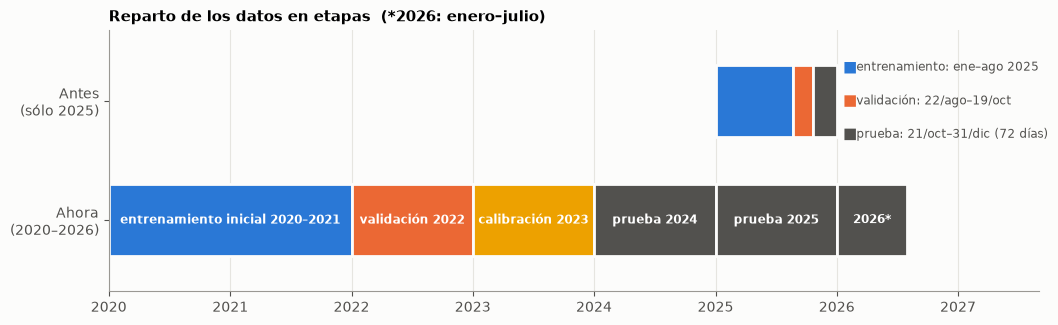

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.4))
T = pd.Timestamp
def barra(y, ini, fin, color, texto, alto=0.6):
    i, f = T(ini), T(fin)
    ax.barh(y, f - i, left=i, height=alto, color=color, edgecolor='#fcfcfb', linewidth=2)
    ax.text(i + (f - i) / 2, y, texto, ha='center', va='center', fontsize=8.5, color='white', weight='bold')

# Antes: sólo 2025
barra(1, '2025-01-01', '2025-08-22', AZUL, '')
barra(1, '2025-08-22', '2025-10-20', NARANJA, '')
barra(1, '2025-10-21', '2026-01-01', TINTA2, '')
for yy, color, txt in [(1.28, AZUL, 'entrenamiento: ene–ago 2025'), (1.0, NARANJA, 'validación: 22/ago–19/oct'),
                       (0.72, TINTA2, 'prueba: 21/oct–31/dic (72 días)')]:
    ax.text(T('2026-01-20'), yy, '■', color=color, va='center', fontsize=11)
    ax.text(T('2026-03-01'), yy, txt, color=TINTA2, va='center', fontsize=8.5)
# Ahora: 2020-2026
barra(0, '2020-01-01', '2022-01-01', AZUL, 'entrenamiento inicial 2020–2021')
barra(0, '2022-01-01', '2023-01-01', NARANJA, 'validación 2022')
barra(0, '2023-01-01', '2024-01-01', AMARILLO, 'calibración 2023')
barra(0, '2024-01-01', '2025-01-01', TINTA2, 'prueba 2024')
barra(0, '2025-01-01', '2026-01-01', TINTA2, 'prueba 2025')
barra(0, '2026-01-01', '2026-08-01', TINTA2, '2026*')
ax.set_yticks([1, 0], ['Antes\n(sólo 2025)', 'Ahora\n(2020–2026)'])
ax.set_ylim(-0.6, 1.6); ax.set_xlim(T('2020-01-01'), T('2027-09-01')); ax.grid(axis='y', visible=False)
ax.set_title('Reparto de los datos en etapas  (*2026: enero–julio)', loc='left')
guardar(fig, '02_reparto_etapas')

| | Antes (sólo 2025) | Ahora (2020–2026) |
|---|---|---|
| Datos | 1 año, 8 760 horas | 7 años, 57 696 horas |
| Cómo se cortó | 80 % / 20 % de las filas: entrena ene–oct, prueba 21/oct–31/dic | por años completos |
| Validación | último 20 % del entrenamiento (≈ 22/ago–19/oct) | todo 2022 |
| Umbral | percentil 95 del **propio entrenamiento** (CCA 14.75 ppb; luego operativo 22.6) | percentil 95 de **2023**, un año que el modelo no vio |
| Prueba | 72 días de otoño-invierno, ozono bajo, **ningún día ≥155** | 3 años completos (2026 parcial), **32 días ≥155** |
| Modelos | CCA (piloto) + 27 estaciones | 31 estaciones con el mismo protocolo |

**Lo más importante del cambio:** antes la prueba era sólo otoño-invierno; nunca vio la
temporada de ozono alto (feb–jun) ni una contingencia. Ahora la prueba incluye tres
temporadas altas completas.

## 3. Los datos de siete años

La línea es la lectura más alta del día en toda la red de 33 estaciones. La franja gris
de 2025 es el periodo de prueba que usábamos antes: se ve que cae justo donde el ozono
es bajo.

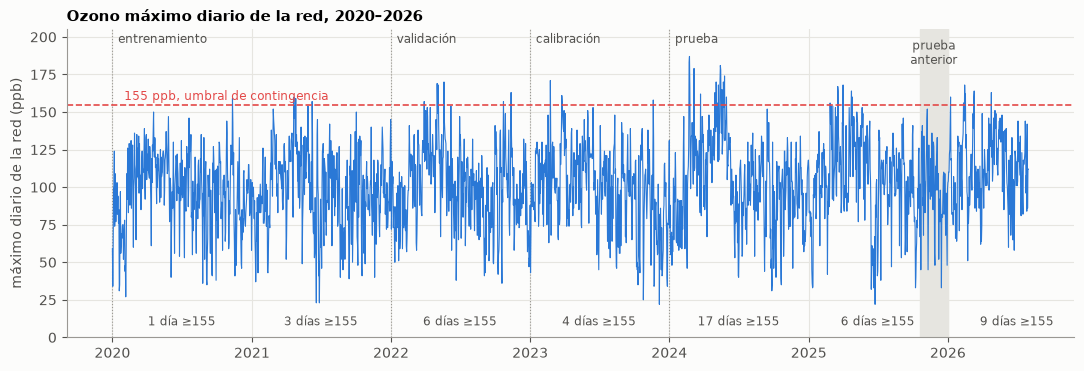

In [5]:
diario = ctx['valores'].max(axis=1).resample('D').max()
fig, ax = plt.subplots(figsize=(13, 4))
ax.axvspan(T('2025-10-21'), T('2025-12-31'), color='#e6e5e0', zorder=0)
ax.text(T('2025-11-25'), 182, 'prueba\nanterior', ha='center', fontsize=8.5, color=TINTA2)
for ini, fin, txt in [('2020-01-01', '2022-01-01', 'entrenamiento'), ('2022-01-01', '2023-01-01', 'validación'),
                      ('2023-01-01', '2024-01-01', 'calibración'), ('2024-01-01', '2026-08-01', 'prueba')]:
    ax.axvline(T(ini), color=GRIS, lw=0.8, ls=':')
    ax.text(T(ini) + pd.Timedelta(days=15), 196, txt, fontsize=8.5, color=TINTA2)
ax.plot(diario.index, diario, color=AZUL, lw=0.8)
ax.axhline(155, color=CRITICO, lw=1.2, ls='--')
ax.text(T('2020-02-01'), 158, '155 ppb, umbral de contingencia', color=CRITICO, fontsize=8.5)
for anio in range(2020, 2027):
    n = int((diario[str(anio)] >= 155).sum())
    ax.text(T(f'{anio}-07-01'), 8, f'{n} día{"s" if n != 1 else ""} ≥155', ha='center', fontsize=8.5, color=TINTA2)
ax.set_ylim(0, 205); ax.set_ylabel('máximo diario de la red (ppb)')
ax.set_title('Ozono máximo diario de la red, 2020–2026', loc='left')
guardar(fig, '03_maximo_diario')

Lecciones del inventario (notebook 10) que condicionan todo lo demás:

- El formato es el mismo en los siete años; el faltante siempre viene como `-99`.
- No todas las estaciones operaron todos los años: XAL no tiene datos en 2020–2022 y
  HGM no tiene en 2021–2022. Por eso HGM y XAL **no tienen detector** propio.
- 2024 es el año con más contingencias: 17 días con alguna estación ≥155 ppb.

## 4. Qué ve el modelo para estimar una hora

**Esto no cambió entre 2025 y ahora: es el mismo V4.** Para estimar la estación objetivo
a la hora t, el modelo recibe una **ventana**: las 24 horas anteriores de las otras 32
estaciones. Cada hora trae 66 números:

- 32 lecturas de las vecinas, **normalizadas** (se les resta su promedio y se dividen
  entre su variación típica, para que todas queden en escala parecida);
- 32 **máscaras**: 1 si hubo dato, 0 si faltó;
- 2 números con la **hora del día** en forma de círculo (seno y coseno), para que las
  23:00 y las 00:00 queden juntas.

Además está el **perfil adaptativo**: el promedio de la propia estación a esa misma hora
en los 14 días anteriores. El modelo **no** adivina el ozono completo: adivina **cuánto
se va a alejar del perfil**. La predicción final es `perfil + corrección`.

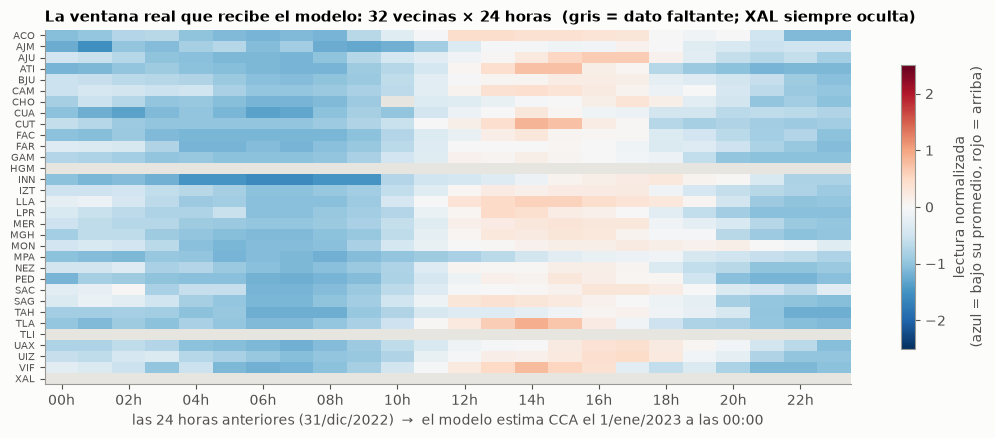

In [6]:
X = pd.read_csv(SAL / 'ejemplos_etapas/calibracion_20230101_00_entrada_24x66.csv', index_col=0, parse_dates=True)
val = X[[c for c in X.columns if c.endswith('_valor')]]
msk = X[[c for c in X.columns if c.endswith('_mascara')]].to_numpy()
mat = np.where(msk == 1, val.to_numpy(), np.nan)
fig, ax = plt.subplots(figsize=(13, 4.6))
cm = plt.get_cmap('RdBu_r').copy(); cm.set_bad('#e6e5e0')
im = ax.imshow(mat.T, aspect='auto', cmap=cm, vmin=-2.5, vmax=2.5)
ax.set_yticks(range(val.shape[1]), [c.replace('_valor', '') for c in val.columns], fontsize=7)
ax.set_xticks(range(0, 24, 2), [f'{h:02d}h' for h in X.index.hour[::2]])
ax.set_xlabel('las 24 horas anteriores (31/dic/2022)  →  el modelo estima CCA el 1/ene/2023 a las 00:00')
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label('lectura normalizada\n(azul = bajo su promedio, rojo = arriba)')
ax.set_title('La ventana real que recibe el modelo: 32 vecinas × 24 horas  (gris = dato faltante; XAL siempre oculta)', loc='left')
guardar(fig, '04_ventana')

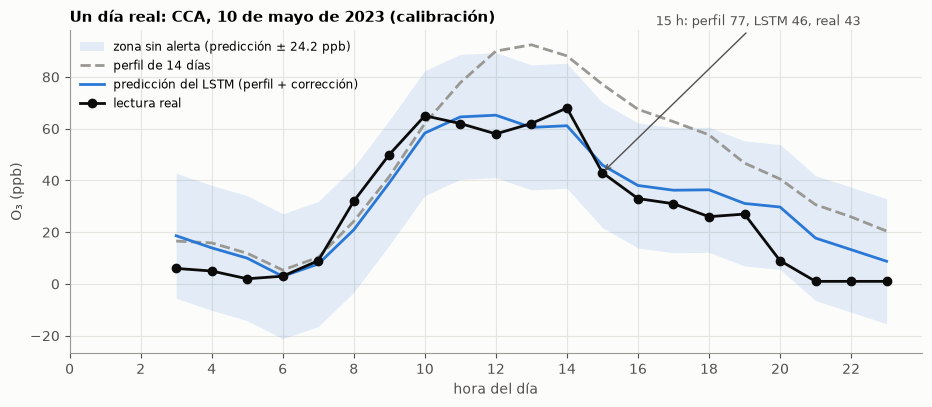

In [7]:
cal = pd.read_csv(EST / 'CCA/calibracion_2023.csv.gz', parse_dates=['timestamp'])
umbral_cca = float((EST / 'CCA/umbral_p95_cal2023.txt').read_text())
dia = cal[cal.timestamp.dt.date == pd.Timestamp('2023-05-10').date()]
fig, ax = plt.subplots(figsize=(11, 4.2))
h = dia.timestamp.dt.hour
ax.fill_between(h, dia.predicho_ppb - umbral_cca, dia.predicho_ppb + umbral_cca, color=AZUL, alpha=0.12, lw=0,
                label=f'zona sin alerta (predicción ± {umbral_cca:.1f} ppb)')
ax.plot(h, dia.base_ppb, color=GRIS, ls='--', label='perfil de 14 días')
ax.plot(h, dia.predicho_ppb, color=AZUL, label='predicción del LSTM (perfil + corrección)')
ax.plot(h, dia.original_ppb, color=TINTA, marker='o', label='lectura real')
r15 = dia[h == 15].iloc[0]
ax.annotate(f'15 h: perfil {r15.base_ppb:.0f}, LSTM {r15.predicho_ppb:.0f}, real {r15.original_ppb:.0f}',
            xy=(15, r15.original_ppb), xytext=(16.5, 100), fontsize=9, color=TINTA2,
            arrowprops=dict(arrowstyle='->', color=TINTA2))
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('hora del día'); ax.set_ylabel('O₃ (ppb)')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_title('Un día real: CCA, 10 de mayo de 2023 (calibración)', loc='left')
guardar(fig, '05_dia_ejemplo')

**Cómo leer la gráfica:** el perfil (gris) esperaba un día como los anteriores, con
picos de 75–100 ppb. Ese día el ozono vino más bajo. El LSTM lo notó en las vecinas y
corrigió su predicción hacia abajo (azul), muy cerca de la lectura real (negro). Mientras
la lectura quede dentro de la franja azul, no hay alerta. Si un ataque la saca de la
franja, suena la alerta.

## 5. Cómo aprendió

**Analogía:** el modelo es un estudiante con un cuaderno de ejercicios resueltos (los
ejemplos de 2020–2021). Una **época** es una pasada completa por el cuaderno. Después
de cada época presenta un **examen con ejercicios que no vio** (2022).

El **error** se mide como el promedio de los errores al cuadrado (ppb²); aquí lo
mostramos ya con **raíz cuadrada**, en ppb, para que se lea como «se equivoca unos X ppb».

| | Antes (sólo 2025) | Ahora |
|---|---|---|
| Examen para decidir cuándo parar | último 20 % del entrenamiento (ago–oct 2025) | 2022 completo |
| Modelo final | el mismo que se entrenó (30 épocas en CCA) | uno **nuevo**, entrenado E épocas con 2020–2022 |

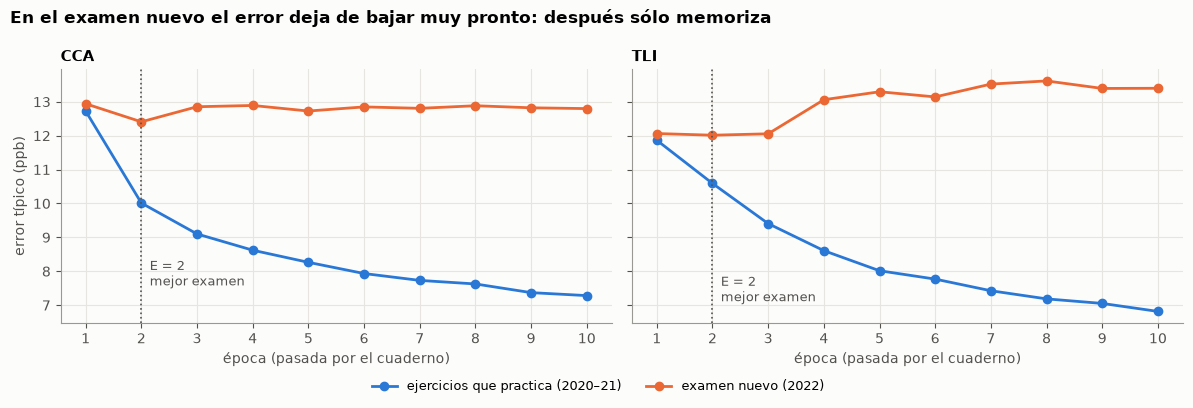

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, obj in zip(axes, ['CCA', 'TLI']):
    hs = pd.read_csv(EST / obj / 'seleccion/historia_seleccion.csv', index_col=0)
    E = json.loads((EST / obj / 'configuracion.json').read_text())['epoca_E']
    ax.plot(hs.index, np.sqrt(hs['loss']), color=AZUL, marker='o', label='ejercicios que practica (2020–21)')
    ax.plot(hs.index, np.sqrt(hs['val_loss']), color=NARANJA, marker='o', label='examen nuevo (2022)')
    ax.axvline(E, color=TINTA2, ls=':', lw=1.2)
    ax.text(E + 0.15, np.sqrt(hs['loss']).min() + 0.3, f'E = {E}\nmejor examen', fontsize=9, color=TINTA2)
    ax.set_title(obj, loc='left'); ax.set_xlabel('época (pasada por el cuaderno)')
    ax.set_xticks(hs.index)
axes[0].set_ylabel('error típico (ppb)')
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('En el examen nuevo el error deja de bajar muy pronto: después sólo memoriza', x=0.01, ha='left',
             fontweight='bold')
fig.tight_layout(); guardar(fig, '06_curvas_aprendizaje')

**Qué pasó:** en los ejercicios que repite, el error baja siempre (azul). En el examen
de 2022 (naranja) mejora una o dos épocas y luego se estanca o empeora. Eso es
**sobreajuste**: el modelo empieza a memorizar 2020–2021 en vez de aprender patrones que
sirvan para otro año. Por eso se elige **E**, la época del mejor examen, y el modelo
definitivo se entrena desde cero sólo E épocas con 2020–2022.

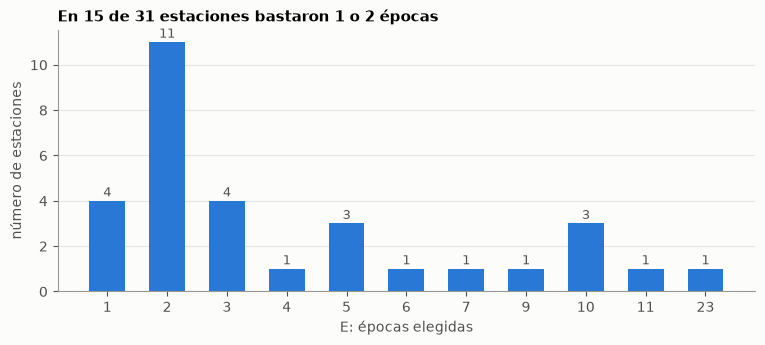

In [9]:
cfgs = pd.DataFrame([json.loads(p.read_text()) for p in sorted(EST.glob('*/configuracion.json'))])
cuenta = cfgs.epoca_E.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(cuenta.index.astype(str), cuenta.values, color=AZUL, width=0.6)
for x, y in zip(cuenta.index.astype(str), cuenta.values):
    ax.text(x, y + 0.2, str(y), ha='center', fontsize=9, color=TINTA2)
ax.set_xlabel('E: épocas elegidas'); ax.set_ylabel('número de estaciones'); ax.grid(axis='x', visible=False)
ax.set_title(f'En {int((cfgs.epoca_E <= 2).sum())} de {len(cfgs)} estaciones bastaron 1 o 2 épocas', loc='left')
guardar(fig, '07_epocas_E')

Que E sea tan pequeño en la mitad de las estaciones dice algo de los datos: lo que se
puede **generalizar de un año a otro** se aprende muy rápido; lo demás son
particularidades de cada año (deriva). La única estación con E grande es AJM (23), que
tenía muy pocos datos en 2020–2021.

## 6. Calibración: el umbral de alerta

Con el modelo ya terminado se predijo cada hora de 2023 y se midió el **residuo**
(`lectura − predicción`). El umbral es el **percentil 95** de esos residuos en valor
absoluto: el 95 % de las lecturas limpias quedan dentro, y sólo el 5 % daría alerta.

| | Antes (sólo 2025) | Ahora |
|---|---|---|
| Residuos usados | los del propio entrenamiento (el modelo ya los había visto) | los de 2023 (no vistos) |
| Umbral de CCA | 14.75 ppb (p95) → 22.6 ppb (operativo, elegido después) | 24.16 ppb |
| Umbrales de la red | p95 del entrenamiento de cada estación | 18.9 a 32.5 ppb (mediana 22.4) |

Un umbral calculado sobre datos que el modelo ya vio sale **demasiado bajo** (el modelo
se equivoca menos en lo que memorizó), y en datos nuevos suena de más. Por eso ahora se
calibra con un año aparte.

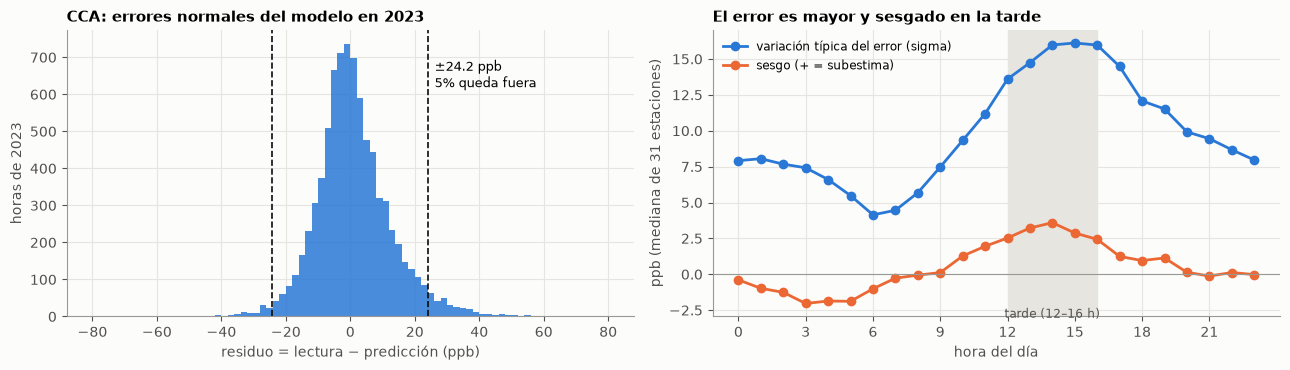

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
ax.hist(cal.residuo_ppb, bins=np.arange(-80, 81, 2), color=AZUL, alpha=0.85)
for s in (-1, 1):
    ax.axvline(s * umbral_cca, color=TINTA, ls='--', lw=1.2)
fuera = (cal.residuo_ppb.abs() > umbral_cca).mean()
ax.text(umbral_cca + 2, ax.get_ylim()[1] * 0.8, f'±{umbral_cca:.1f} ppb\n{fuera:.0%} queda fuera', fontsize=9)
ax.set_xlabel('residuo = lectura − predicción (ppb)'); ax.set_ylabel('horas de 2023')
ax.set_title('CCA: errores normales del modelo en 2023', loc='left')

ax = axes[1]
filas = []
for obj in cfgs.objetivo:
    c = pd.read_csv(EST / obj / 'calibracion_2023.csv.gz', parse_dates=['timestamp'])
    filas.append(c.assign(hora=c.timestamp.dt.hour).groupby('hora').residuo_ppb.agg(['mean', lambda x: x.std(ddof=0)])
                 .set_axis(['sesgo', 'sigma'], axis=1).assign(obj=obj))
porhora = pd.concat(filas).drop(columns='obj').groupby('hora').median()
ax.plot(porhora.index, porhora.sigma, color=AZUL, marker='o', label='variación típica del error (sigma)')
ax.plot(porhora.index, porhora.sesgo, color=NARANJA, marker='o', label='sesgo (+ = subestima)')
ax.axhline(0, color=GRIS, lw=0.8)
ax.axvspan(12, 16, color='#e6e5e0', zorder=0); ax.text(14, porhora.sesgo.min() - 0.3, 'tarde (12–16 h)', ha='center', va='top', fontsize=8.5, color=TINTA2)
ax.set_xticks(range(0, 24, 3)); ax.set_xlabel('hora del día'); ax.set_ylabel('ppb (mediana de 31 estaciones)')
ax.legend(fontsize=8.5, loc='upper left'); ax.set_title('El error es mayor y sesgado en la tarde', loc='left')
fig.tight_layout(); guardar(fig, '08_calibracion')

**Dos lecturas importantes:**

1. La mayoría de los errores son pequeños; el umbral corta la «cola» del 5 %.
2. En la tarde (12–16 h) el modelo se equivoca más (sigma ≈15 ppb) y tiende a
   **subestimar** (sesgo positivo). Es justo la franja de las contingencias: ahí un
   ataque mediano se esconde mejor entre el error normal.

## 7. ¿El LSTM sirve más que el perfil?

Una prueba de humildad: si en lugar del LSTM usáramos sólo el perfil de 14 días, ¿qué
error tendríamos? La barra muestra cuánto **reduce** el LSTM el error medio (MAE) en 2023.

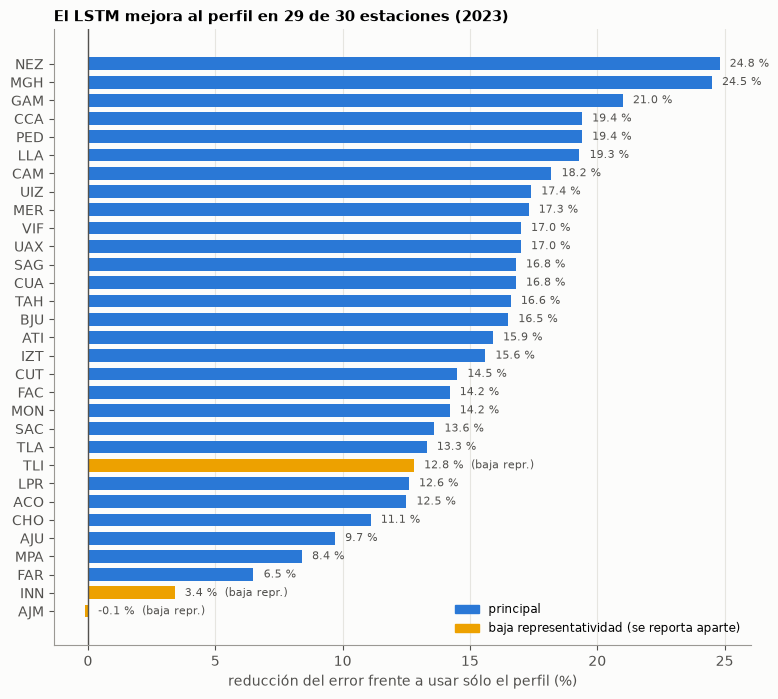

In [11]:
e = estado[estado.entrenado].sort_values('mejora_vs_perfil_pct')
fig, ax = plt.subplots(figsize=(9, 8))
col = [AZUL if c == 'principal' else AMARILLO for c in e.clasificacion]
ax.barh(e.objetivo, e.mejora_vs_perfil_pct, color=col, height=0.7)
for y, (v, c) in enumerate(zip(e.mejora_vs_perfil_pct, e.clasificacion)):
    ax.text(max(v, 0) + 0.4, y, f'{v:.1f} %' + ('  (baja repr.)' if c != 'principal' else ''),
            va='center', fontsize=8, color=TINTA2)
ax.axvline(0, color=TINTA2, lw=1)
ax.set_xlabel('reducción del error frente a usar sólo el perfil (%)'); ax.grid(axis='y', visible=False)
ax.legend(handles=[mpatches.Patch(color=AZUL, label='principal'),
                   mpatches.Patch(color=AMARILLO, label='baja representatividad (se reporta aparte)')],
          loc='lower right', fontsize=8.5)
ax.set_title('El LSTM mejora al perfil en 29 de 30 estaciones (2023)', loc='left')
guardar(fig, '09_mejora_vs_perfil')

La mediana es −16 %. **AJM** no mejora: sólo tenía 4 meses de datos en 2020–2021, y por
eso se marcó como de «baja representatividad» **antes** de entrenar. El resultado
confirma que esa precaución era correcta.

## 8. Sin ataques: falsas alarmas en años nuevos

En 2023 el umbral daba alerta en el 5 % de las lecturas limpias **por construcción**.
¿Qué pasa en años que el modelo nunca vio? Cada punto es una estación.

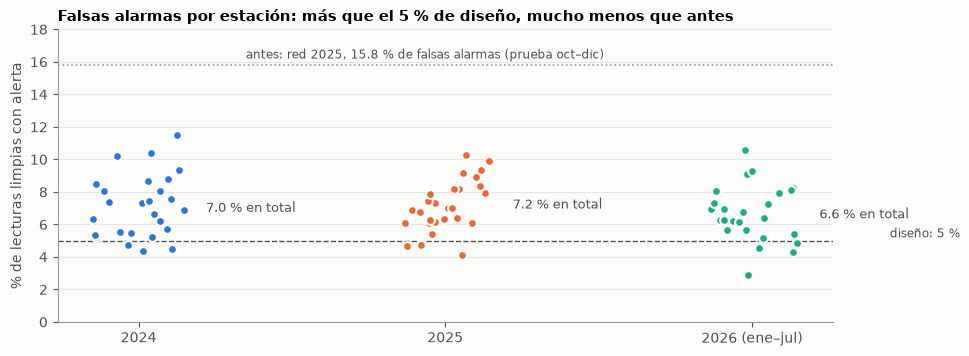

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.8))
rng = np.random.default_rng(0)
for i, anio in enumerate([2024, 2025, 2026]):
    d = limpias[(limpias.anio == anio) & (limpias.clasificacion == 'principal')]
    ax.scatter(i + rng.uniform(-0.15, 0.15, len(d)), 100 * d.fpr, s=40, color=COLOR_ANIO[anio],
               edgecolor='#fcfcfb', linewidth=1.5, zorder=3)
    micro = 100 * d.falsas_alarmas.sum() / d.n.sum()
    ax.text(i + 0.22, micro, f'{micro:.1f} % en total', va='center', fontsize=9, color=TINTA2)
ax.axhline(5, color=TINTA2, ls='--', lw=1); ax.text(2.45, 5.2, 'diseño: 5 %', fontsize=8.5, color=TINTA2)
ax.axhline(15.8, color=GRIS, ls=':', lw=1.2)
ax.text(0.35, 16.2, 'antes: red 2025, 15.8 % de falsas alarmas (prueba oct–dic)', fontsize=8.5, color=TINTA2)
ax.set_xticks([0, 1, 2], ['2024', '2025', '2026 (ene–jul)']); ax.set_ylim(0, 18)
ax.set_ylabel('% de lecturas limpias con alerta'); ax.grid(axis='x', visible=False)
ax.set_title('Falsas alarmas por estación: más que el 5 % de diseño, mucho menos que antes', loc='left')
guardar(fig, '10_falsas_alarmas')

- En años nuevos suena en falso **≈7 %** de las veces, no 5 %: el ozono de cada año es un
  poco distinto (deriva), y el modelo se equivoca un poco más que en 2023.
- **Antes** la red de 2025 sonaba en falso **15.8 %**, porque su umbral salía del propio
  entrenamiento. Calibrar con un año aparte reduce las falsas alarmas a menos de la mitad.

## 9. Por qué unos bits se detectan y otros no

El detector compara lo recibido con lo esperado. Un ataque suma o resta 2^k ppb al
residuo. Si el residuo atacado sale de la franja `± umbral`, suena la alerta. La gráfica
toma los errores **reales** de CCA en 2023 y les suma el desplazamiento de cada bit (con
signo al azar, como un atacante ciego).

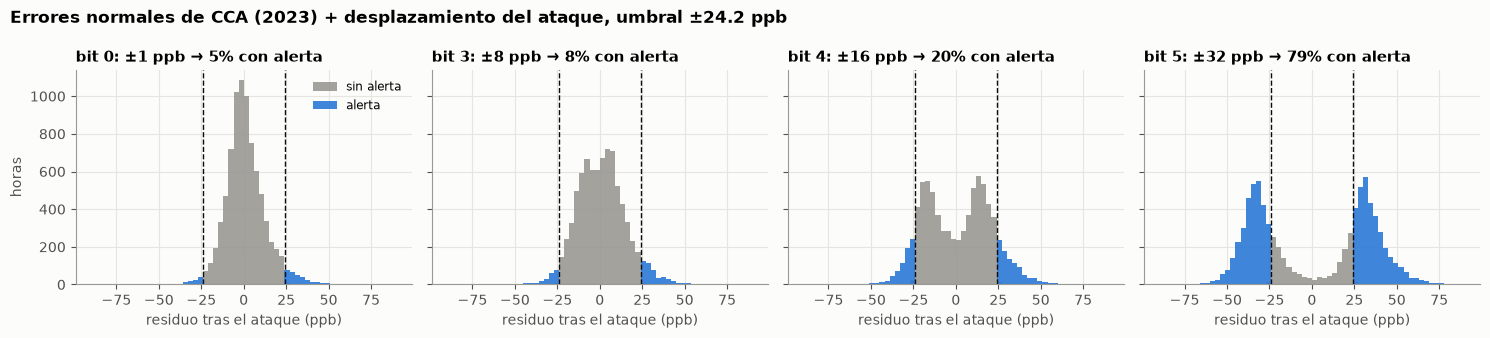

In [13]:
r = cal.residuo_ppb.to_numpy()
signo = np.random.default_rng(1).choice([-1, 1], len(r))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, bit in zip(axes, [0, 3, 4, 5]):
    d = r + signo * 2 ** bit
    det = np.abs(d) > umbral_cca
    bins = np.arange(-90, 91, 3)
    ax.hist(d[~det], bins=bins, color=GRIS, alpha=0.9, label='sin alerta')
    ax.hist(d[det], bins=bins, color=AZUL, alpha=0.9, label='alerta')
    for s in (-1, 1):
        ax.axvline(s * umbral_cca, color=TINTA, ls='--', lw=1)
    ax.set_title(f'bit {bit}: ±{2**bit} ppb → {det.mean():.0%} con alerta', loc='left')
    ax.set_xlabel('residuo tras el ataque (ppb)')
axes[0].set_ylabel('horas'); axes[0].legend(fontsize=8.5)
fig.suptitle(f'Errores normales de CCA (2023) + desplazamiento del ataque, umbral ±{umbral_cca:.1f} ppb',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout(); guardar(fig, '11_por_que_bits')

- Con **±1 ppb** (bit 0) la nube de errores casi no se mueve: suena igual que sin ataque.
- Con **±16** (bit 4) una parte cruza la línea, pero la mayoría sigue escondida en el
  error normal.
- Con **±32** (bit 5) la mayor parte ya sale de la franja.
- Con ±64 o ±128 todo sale: imposible esconderlo.

## 10. Resultados contra ataques, antes y ahora

**Muestra pareada al 5 %:** en cada estación se elige al azar 5 % de las lecturas, se
atacan con cada bit (las mismas lecturas para todos los bits) y se cuenta qué porcentaje
de ataques sonó (**recall**). Pero el recall solo engaña: un detector que sonara siempre
tendría 100 %. Por eso se muestra al lado la **tasa de falsas alarmas** (FPR).

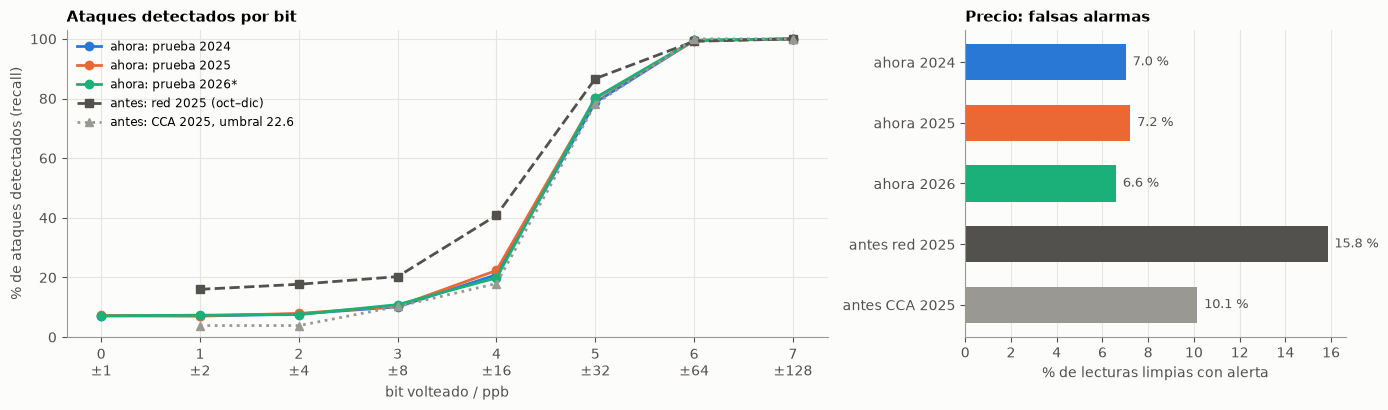

In [14]:
p25 = pd.read_csv(R25 / 'metricas_pareadas.csv').groupby('bit')[['tp', 'fn', 'fp', 'tn']].sum()
p25['recall'] = 100 * p25.tp / (p25.tp + p25.fn); p25['fpr'] = 100 * p25.fp / (p25.fp + p25.tn)
cca25 = pd.read_csv(RAIZ / 'results/metricas_operativas_cca_bits_1_7.csv').set_index('bit')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw=dict(width_ratios=[2, 1]))
ax = axes[0]
for anio in [2024, 2025, 2026]:
    d = pareada[(pareada.anio == anio) & (pareada.grupo == 'principal')]
    ax.plot(d.bit, d.recall_micro_pct, marker='o', color=COLOR_ANIO[anio], label=f'ahora: prueba {anio}' + ('*' if anio == 2026 else ''))
ax.plot(p25.index, p25.recall, marker='s', color=TINTA2, ls='--', label='antes: red 2025 (oct–dic)')
ax.plot(cca25.index, cca25.recall_pct, marker='^', color=GRIS, ls=':', label='antes: CCA 2025, umbral 22.6')
ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_xlabel('bit volteado / ppb')
ax.set_ylabel('% de ataques detectados (recall)'); ax.set_ylim(0, 103); ax.legend(fontsize=8.5, loc='upper left')
ax.set_title('Ataques detectados por bit', loc='left')

ax = axes[1]
fprs = {f'ahora {a}': pareada[(pareada.anio == a) & (pareada.grupo == 'principal')].fpr_micro_pct.iat[0] for a in [2024, 2025, 2026]}
fprs['antes red 2025'] = p25.fpr.iat[0]
fprs['antes CCA 2025'] = cca25.fpr_pct.iat[0]
cols = [AZUL, NARANJA, AQUA, TINTA2, GRIS]
ax.barh(list(fprs)[::-1], list(fprs.values())[::-1], color=cols[::-1], height=0.6)
for y, v in enumerate(list(fprs.values())[::-1]):
    ax.text(v + 0.3, y, f'{v:.1f} %', va='center', fontsize=9, color=TINTA2)
ax.set_xlabel('% de lecturas limpias con alerta'); ax.grid(axis='y', visible=False)
ax.set_title('Precio: falsas alarmas', loc='left')
fig.tight_layout(); guardar(fig, '12_recall_y_fpr')

**Cómo leerlo, sin engañarse:**

- Las tres pruebas nuevas (2024, 2025, 2026) dan **casi la misma curva**: el detector se
  comporta de forma estable de un año a otro.
- **Antes**, la red de 2025 detectaba más en los bits 4 y 5 (41 % y 87 % frente a 21 % y
  80 %: **casi el doble en el bit 4**). Pero lo pagaba con **15.8 % de falsas alarmas**, más
  del doble que ahora. La causa principal es el umbral: la mediana de la red era 17.4 ppb
  (calculada con datos ya vistos) y ahora es 22.4 ppb (calculada con 2023). Una franja más
  ancha suena menos en falso, pero deja pasar más ataques medianos.
  Un umbral más bajo atrapa más ataques y también suena más en falso: no es que el
  detector antiguo fuera mejor, es otro punto del mismo compromiso. Además, aquella prueba
  era otoño-invierno (ozono bajo, errores pequeños), más fácil que un año completo.
- En los bits 0 a 2, el recall (≈7 %) es igual a la tasa de falsas alarmas: esas
  «detecciones» habrían sonado sin ataque. El detector **no ve** esos ataques.
- El salto está entre el bit 4 (±16) y el 5 (±32), porque el umbral está en ~19–33 ppb.

## 11. Daño que se escapa: el punto ideal del atacante

Mover el número no basta para hacer daño: el daño es **cambiar una decisión**. El
**barrido** ataca cada lectura con cada bit, de una en una, y pregunta: ¿cambiaría la
decisión? ¿sonaría la alerta? Se cuenta el porcentaje de días con **al menos una
oportunidad de daño que pasaría sin alerta**.

Se mira el **máximo del día de toda la red**, que es lo que define una contingencia:
- *Cambio de banda*: el máximo del día pasa de una banda NOM-172 a otra.
- *Excedencia fabricada*: el máximo era < 155 y el ataque lo sube a ≥ 155.

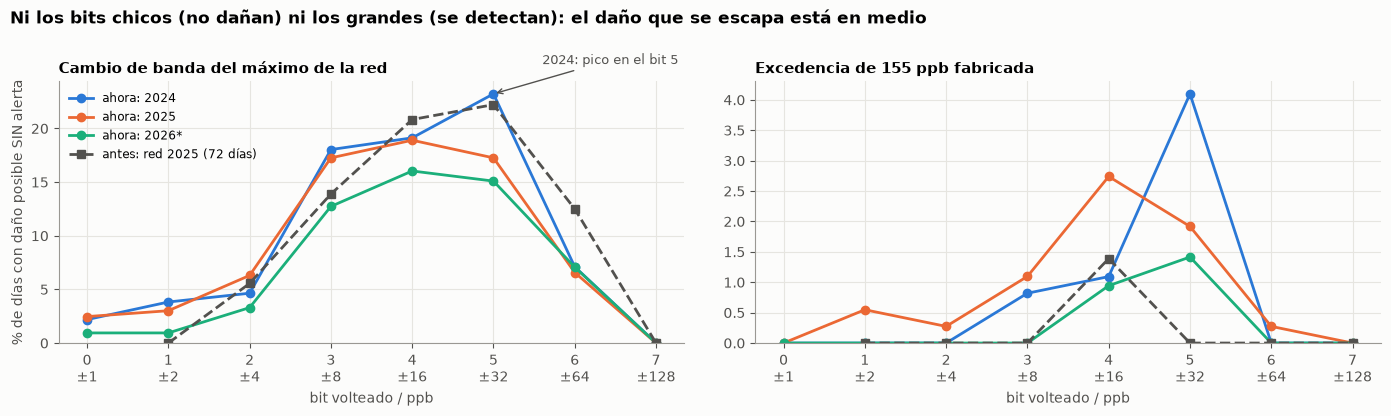

In [15]:
d25 = pd.read_csv(R25 / 'resumen_red_por_bit.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
for ax, tipo, tit in zip(axes, ['cambio_banda_red', 'falsa_fase1'],
                         ['Cambio de banda del máximo de la red', 'Excedencia de 155 ppb fabricada']):
    for anio in [2024, 2025, 2026]:
        g = dias[(dias.anio == anio) & (dias.tipo_dano == tipo)]
        ax.plot(g.bit, g.pct_dias_dano_no_detectado, marker='o', color=COLOR_ANIO[anio],
                label=f'ahora: {anio}' + ('*' if anio == 2026 else ''))
    g = d25[d25.tipo_dano == tipo]
    ax.plot(g.bit, g.pct_dias_dano_no_detectado, marker='s', ls='--', color=TINTA2, label='antes: red 2025 (72 días)')
    ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_xlabel('bit volteado / ppb')
    ax.set_title(tit, loc='left'); ax.set_ylim(bottom=0)
axes[0].set_ylabel('% de días con daño posible SIN alerta'); axes[0].legend(fontsize=8.5)
axes[0].annotate('2024: pico en el bit 5', xy=(5, dias[(dias.anio == 2024) & (dias.tipo_dano == 'cambio_banda_red') & (dias.bit == 5)].pct_dias_dano_no_detectado.iat[0]),
                 xytext=(5.6, 26), fontsize=9, color=TINTA2, arrowprops=dict(arrowstyle='->', color=TINTA2))
fig.suptitle('Ni los bits chicos (no dañan) ni los grandes (se detectan): el daño que se escapa está en medio',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout(); guardar(fig, '13_dano_no_detectado')

Ésta es la gráfica central de la tesis:

- **Bits 0–2:** casi no hay oportunidad de daño; mover 1–4 ppb rara vez cambia una banda.
- **Bits 6–7:** muchísimas oportunidades, pero el detector las atrapa todas.
- **Bits 3–5 (±8 a ±32 ppb):** ahí está el daño que se escapa. El pico cae en el **bit 4 o
  el 5 según el año**: bit 5 en 2024, bit 4 en 2025 y 2026 (diferencias de 1–2 puntos
  entre ambos). En 2024, 85 días (23 %) tenían alguna forma de cambiar la banda del máximo
  de la red sin alerta (bit 5), y 15 días alguna forma de fabricar una excedencia de 155
  ppb sin alerta.
- **Antes**, el experimento de red de 2025 ya mostraba la misma forma para el cambio de
  banda (línea gris), con 72 días de prueba.

Pero aquella prueba sólo tenía 72 días de ozono bajo: su máximo fue 152 ppb, así que
casi no había excedencias que fabricar y **ninguna que ocultar**. **Ahora**, con
tres temporadas altas, se confirma el mismo «punto ideal del atacante» con contingencias
reales.

**Desactivaciones de fase 1 (esconder una excedencia real).** Aquí el denominador justo
**no son todos los días**, sino los días en que de verdad hubo una excedencia que esconder.

      dias_con_excedencia  ocultables  ocultables_sin_alerta  ocultables_sin_detector  pct_sin_alerta
anio                                                                                                 
2024                   17           3                      2                        1            11.8
2025                    6           3                      2                        0            33.3
2026                    9           2                      0                        0             0.0


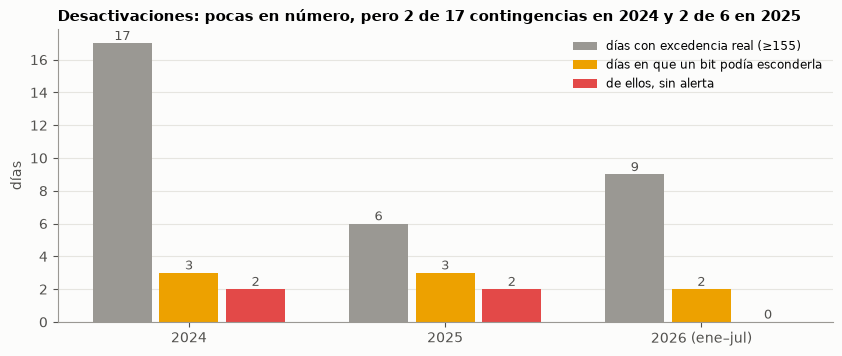

In [16]:
filas = []
for anio in [2024, 2025, 2026]:
    ev = pd.read_parquet(SAL / f'eventos_dano/eventos_{anio}.parquet') if (SAL / f'eventos_dano/eventos_{anio}.parquet').exists() else None
    exc = int(dias[(dias.anio == anio)].dias_con_excedencia_original.iat[0])
    if ev is None:
        print(f'{anio}: falta eventos_dano/ (ejecuta el notebook 13 con CALCULAR = True)'); continue
    an = ev[ev.anulada_fase1]
    filas.append(dict(anio=anio, dias_con_excedencia=exc, ocultables=an.fecha.nunique(),
                      ocultables_sin_alerta=an[an.evaluable & ~an.detectado].fecha.nunique(),
                      ocultables_sin_detector=an[~an.evaluable].fecha.nunique()))
desact = pd.DataFrame(filas).set_index('anio')
desact['pct_sin_alerta'] = (100 * desact.ocultables_sin_alerta / desact.dias_con_excedencia).round(1)
print(desact.to_string())

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(desact)); w = 0.26
for k, (col, color, lab) in enumerate([('dias_con_excedencia', GRIS, 'días con excedencia real (≥155)'),
                                       ('ocultables', AMARILLO, 'días en que un bit podía esconderla'),
                                       ('ocultables_sin_alerta', CRITICO, 'de ellos, sin alerta')]):
    ax.bar(x + (k - 1) * w, desact[col], width=w - 0.03, color=color, label=lab)
    for xi, v in zip(x, desact[col]):
        ax.text(xi + (k - 1) * w, v + 0.2, str(v), ha='center', fontsize=9, color=TINTA2)
ax.set_xticks(x, [f'{a}' + (' (ene–jul)' if a == 2026 else '') for a in desact.index])
ax.set_ylabel('días'); ax.grid(axis='x', visible=False); ax.legend(fontsize=8.5, loc='upper right')
ax.set_title('Desactivaciones: pocas en número, pero 2 de 17 contingencias en 2024 y 2 de 6 en 2025', loc='left')
guardar(fig, '13b_desactivaciones')

- **En número son pocas:** 2 días en 2024 y 2 en 2025 se podían esconder sin alerta.
- **Pero frente a lo que importa no son despreciables:** son **1 de cada 8 contingencias
  de 2024 (12 %) y 1 de cada 3 de 2025 (33 %)**. Y una desactivación es probablemente más
  grave que una activación falsa: la población no se entera de que el aire está mal.
- **Por qué hay pocas oportunidades:** (1) sólo existen en días con excedencia (32 en tres
  años), mientras que una activación falsa se intenta casi cualquier día; (2) en la
  mayoría de esos días varias estaciones pasan de 155 a la vez y bajar una no basta: los 4
  casos ocultables fueron días en que **sólo una** lectura superaba 155 y la siguiente más
  alta quedaba en 151–153 ppb (CCA 6/may/2024 con el bit 4, UAX 25/may/2024, AJM 19/mar/2025
  y UAX 23/abr/2025 con el bit 5); (3) para **bajar** una lectura la casilla atacada tiene
  que valer 1 (156 tiene el bit 4 en 1, pero el bit 5 en 0: voltearlo la sube).
- **Antes** no se podían medir: la prueba de 2025 tuvo como máximo 152 ppb, ninguna
  excedencia que esconder. Por eso los notebooks anteriores sólo estudiaban activaciones.
- Todo esto es con **un solo mensaje** atacado; un atacante que modifique varias
  estaciones el mismo día podría esconder más.

## 12. Las estaciones sin detector

Una lectura de una estación sin modelo puede alterarse sin que nadie la vigile.

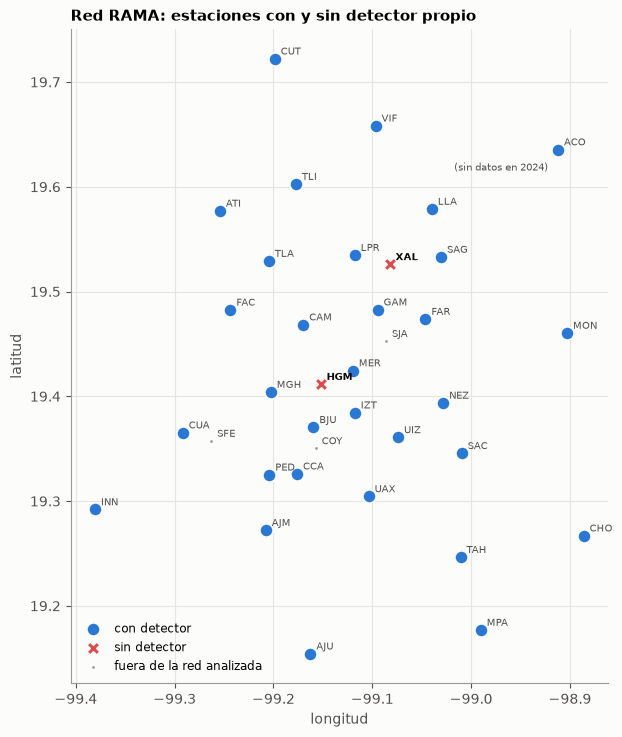

In [17]:
sin = {'HGM', 'XAL'}
g = geo.copy()
g['estado'] = np.where(g.index.isin(sin), 'sin detector',
                       np.where(g.en_matriz_2025, 'con detector', 'fuera de la red analizada'))
fig, ax = plt.subplots(figsize=(8, 8.5))
for est_, color, marker in [('con detector', AZUL, 'o'), ('sin detector', CRITICO, 'X'), ('fuera de la red analizada', GRIS, '.')]:
    d = g[g.estado == est_]
    ax.scatter(d.longitud, d.latitud, s=90 if marker != '.' else 40, color=color, marker=marker,
               edgecolor='#fcfcfb', linewidth=1.2, label=est_, zorder=3)
for s, rr in g.iterrows():
    ax.text(rr.longitud + 0.006, rr.latitud + 0.004, s, fontsize=7.5, color=TINTA if s in sin else TINTA2,
            weight='bold' if s in sin else 'normal')
ax.text(g.loc['ACO', 'longitud'] - 0.01, g.loc['ACO', 'latitud'] - 0.02, '(sin datos en 2024)', fontsize=7, color=TINTA2, ha='right')
ax.set_aspect(1 / np.cos(np.radians(19.4))); ax.set_xlabel('longitud'); ax.set_ylabel('latitud')
ax.legend(fontsize=8.5, loc='lower left')
ax.set_title('Red RAMA: estaciones con y sin detector propio', loc='left')
guardar(fig, '14_mapa_detectores')

En las estaciones con detector, un ataque de ±128 ppb **siempre** se detecta. Pero con
ese mismo ataque sobre HGM, XAL (o ACO en 2024, que no tuvo datos de prueba) se podía
fabricar una excedencia en **306 de 366 días de 2024** sin ninguna evaluación posible.
Para el atacante, la red es tan fuerte como su estación menos protegida. Cubrirlas sería
un experimento nuevo.

## 13. Resumen final

| Pregunta | Antes (sólo 2025) | Ahora (2020–2026) |
|---|---|---|
| ¿Con qué datos? | 1 año | 7 años, 57 696 horas, 33 estaciones |
| ¿Qué modelo? | LSTM V4: ventana 24 h × 66, perfil 14 días | **el mismo V4** |
| ¿Cómo se eligió cuándo parar? | último 20 % de 2025 | año completo 2022 (E = 1–23) |
| ¿Cómo se fijó el umbral? | con el propio entrenamiento | con 2023, año no visto |
| ¿Con qué se probó? | 72 días de otoño-invierno, sin contingencias | 2024, 2025 y 2026 (ene–jul), 32 días ≥155 |
| ¿El LSTM mejora al perfil? | sí en CCA | sí en 29/30 estaciones (−16 % de error, mediana) |
| Falsas alarmas | 15.8 % (red) | ≈7 % |
| Ataques de ±32 ppb detectados | 87 % (red) | ≈80 % |
| Ataques de ±1 a ±4 ppb | no se detectan | no se detectan (≈7 %, igual que las falsas alarmas) |
| Daño que se escapa | bits 3–5 (cambio de banda), sin poder medir ocultamientos | bits 3–5, pico en el bit 4 o 5 según el año, **con contingencias reales** |
| Desactivaciones de fase 1 | no medibles (ninguna excedencia en la prueba) | sin alerta en 2 de 17 contingencias (2024) y 2 de 6 (2025), con un solo mensaje |
| ¿Se reproduce? | sí (CCA) | sí: entrenamiento (CCA, TLI) y evaluación |

**En una frase:** con siete años de datos el mismo detector V4 se comporta de forma
estable en años que nunca vio, suena menos en falso que antes y confirma que el daño que
escapa se concentra en desplazamientos de 8 a 32 ppb (bits 3–5); sus puntos débiles son los ataques
medianos en la tarde, las desactivaciones en días con una sola estación sobre 155 y las
estaciones sin detector.

Todas las figuras de este libro están en `docs/img/lstm_v4_multianual_v1/resumen/`.